# Descriptive analysis

In [1]:
import os
import pandas as pd

# Scatter plots

In [19]:
def plot_scatter_pred_vs_gt(output_path, colname, gt_path, title, save_path, corename_col='corename'):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LinearRegression

    df_gt = pd.read_csv(gt_path)
    df_output = pd.read_csv(output_path)

    # Merge to align x (gt) and y (predicted) by corename — avoids size mismatch
    df_merged = df_gt.merge(df_output, left_on=corename_col, right_on='soil_core')

    x = df_merged['Length(cm)'].values
    y = df_merged[colname].values

    plt.figure(figsize=(12, 8))
    plt.scatter(x, y, alpha=0.7, s=100, label='Data points')
    plt.grid(True)
    plt.xlabel('Ground Truth', fontsize=24)
    plt.ylabel('Predicted', fontsize=24)
    plt.title(title, fontsize=24)

    x_reshaped = x.reshape(-1, 1)
    reg = LinearRegression().fit(x_reshaped, y)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = reg.predict(x_line.reshape(-1, 1))
    plt.plot(x_line, y_line, 'r--', linewidth=3, label='Fitted line')

    plt.legend(fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

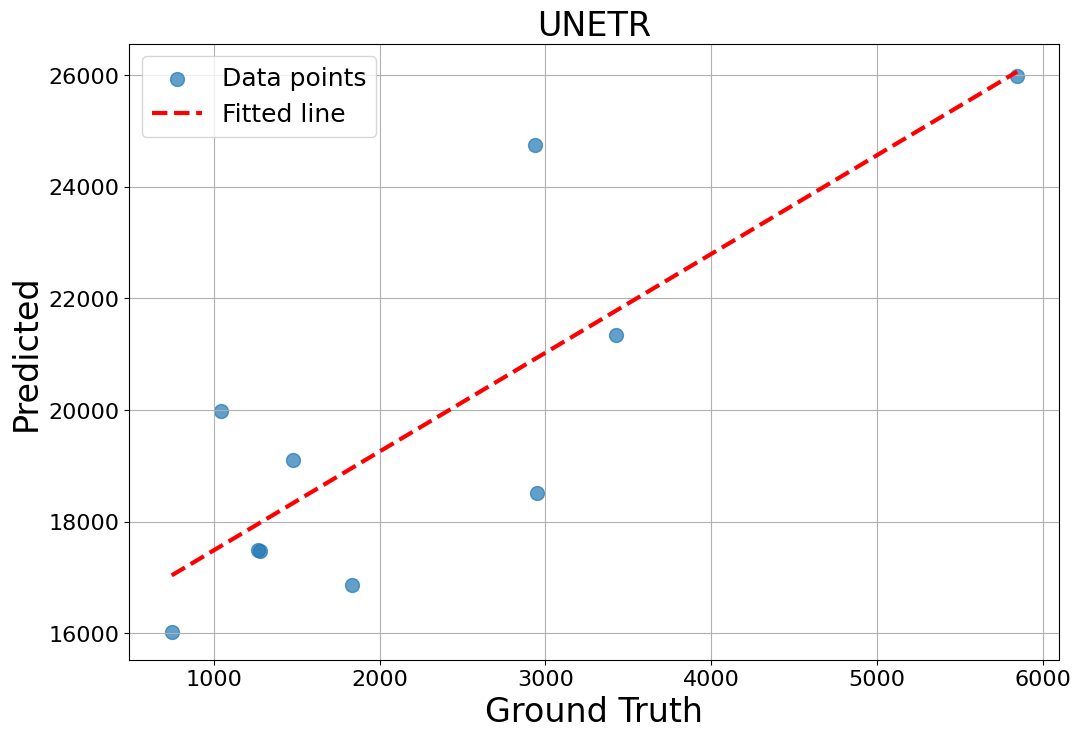

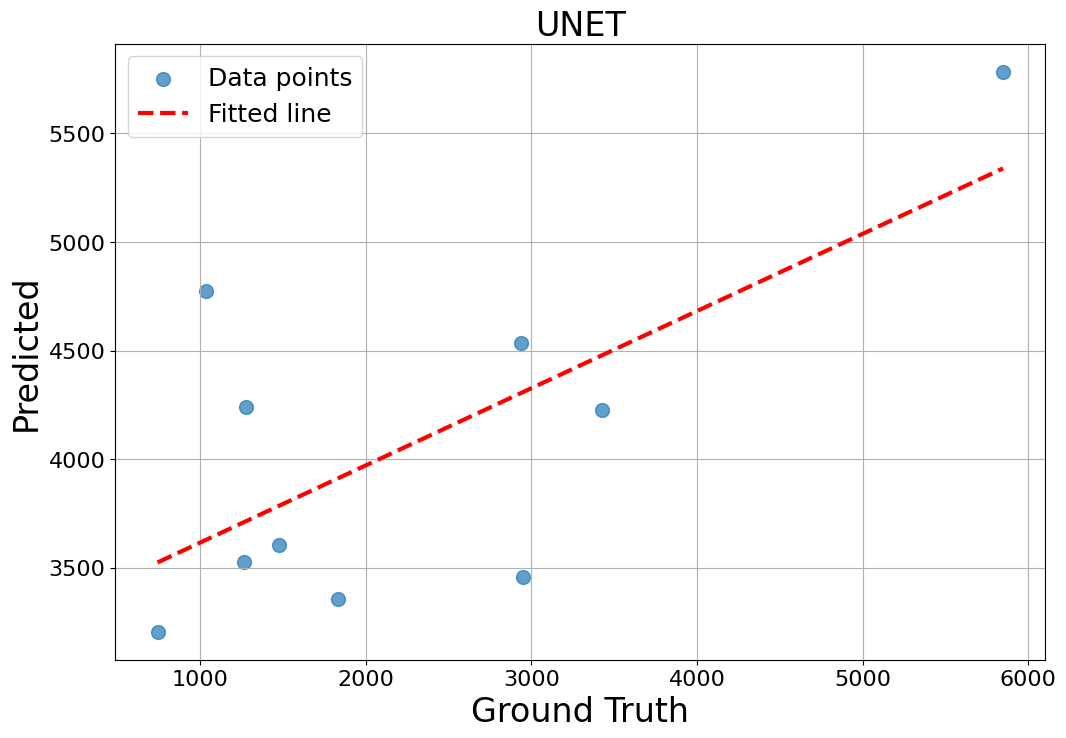

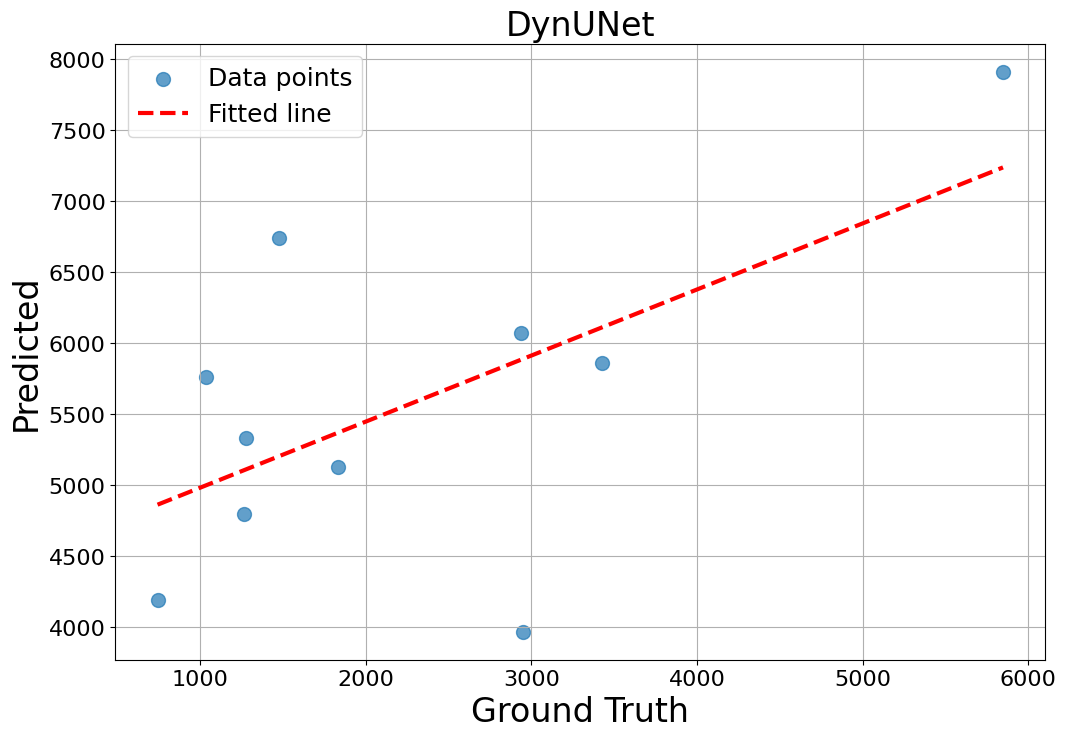

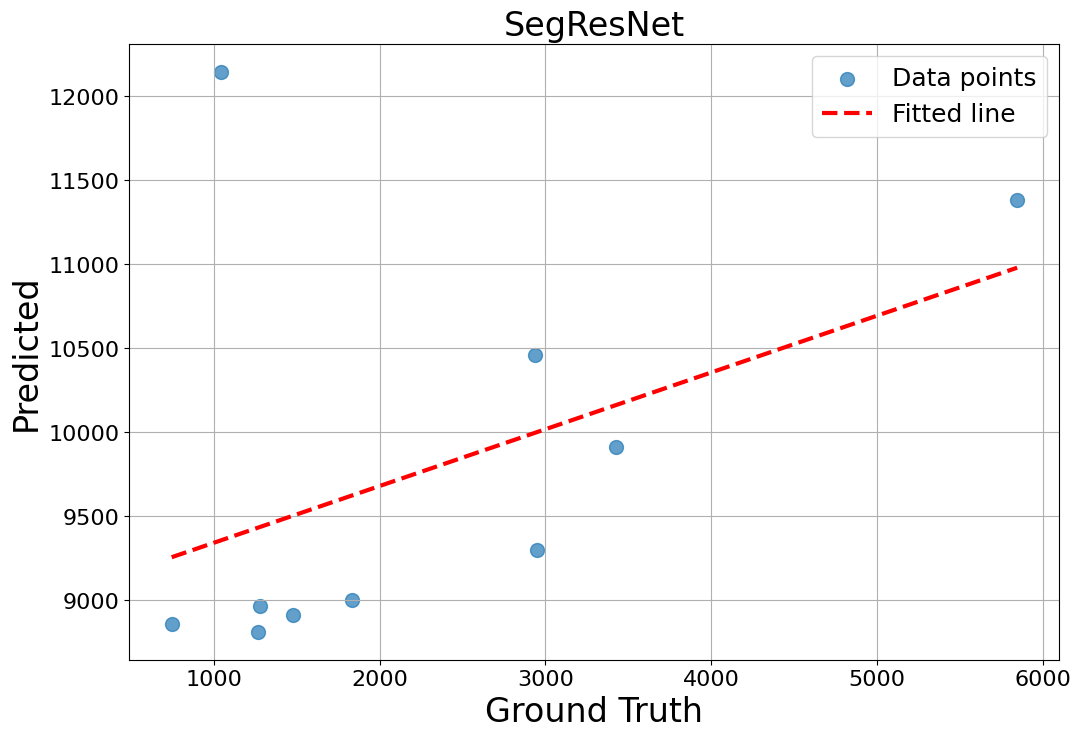

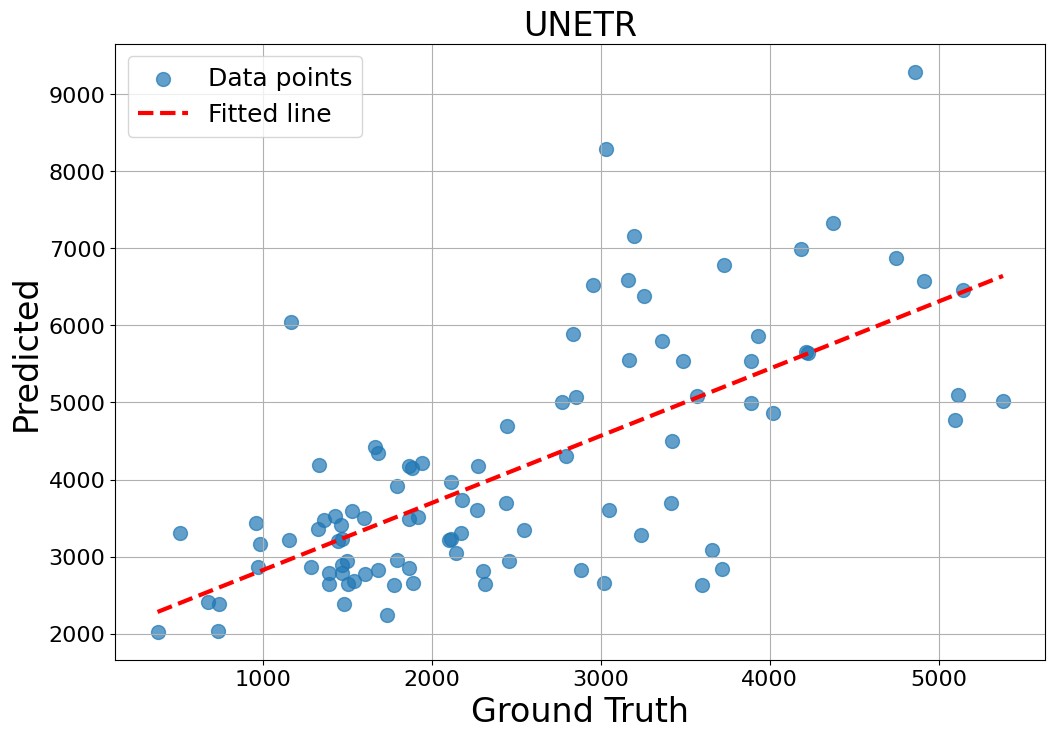

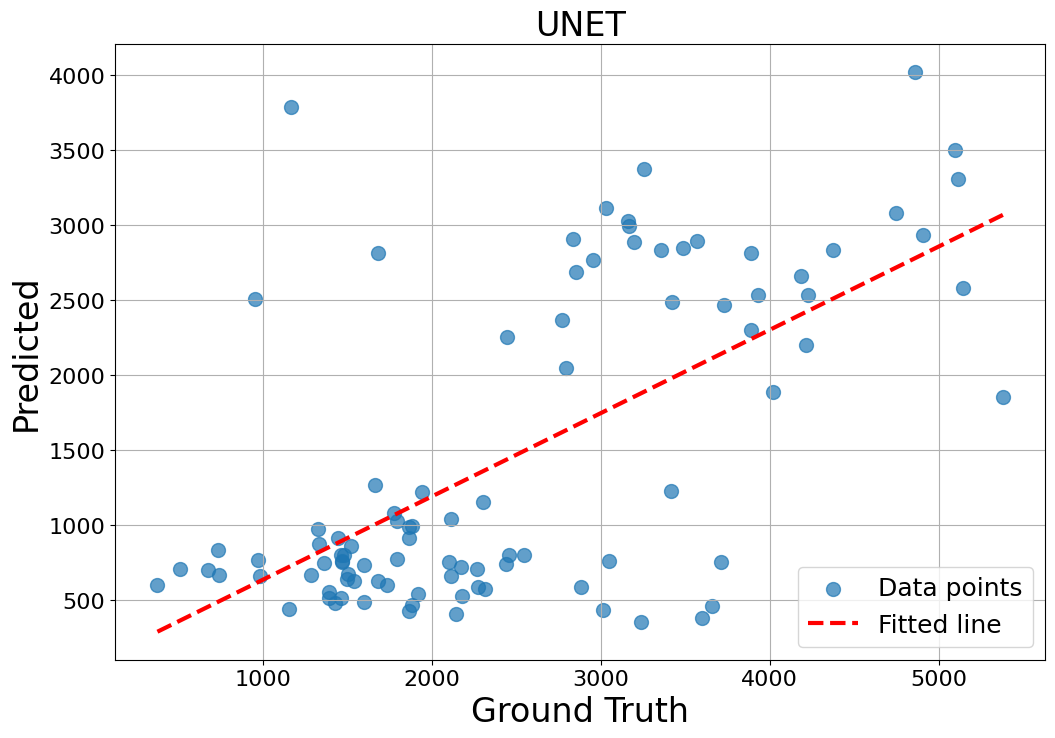

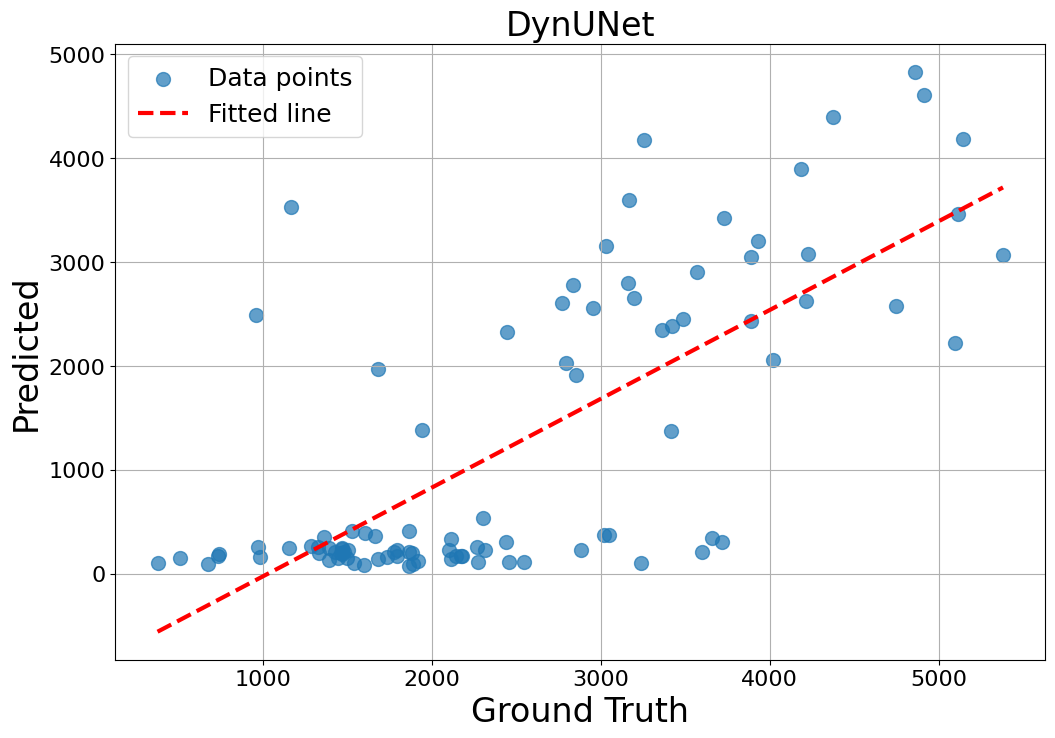

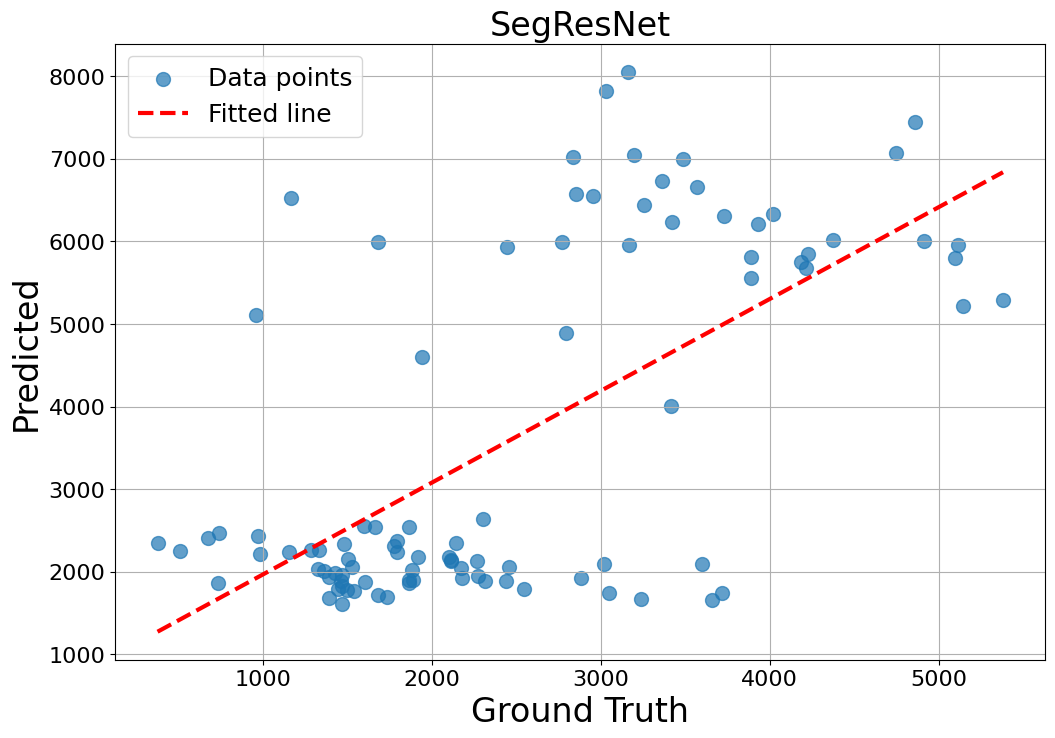

In [21]:
subset_info = [{'ext': "_val",
                'gt': 'CoresGT_val.csv',
                'corename_col': 'corename'},
               {'ext': "",
                'gt': 'MNHT_rootmorphology_GT_v2.csv',
                'corename_col': 'label ID'}]

for subset in subset_info:
    subset_ext = subset['ext']
    title = "UNETR"
    output_path = f"data_info/prediction_unetr{subset_ext}.csv"
    gt_path = os.path.join('data_info',subset["gt"])
    colname = "Root Length Diameter Range 2 (px)"
    save_path = f"outputs/figs_corr_{title}{subset_ext}.png"

    plot_scatter_pred_vs_gt(output_path, colname, gt_path, title, save_path, corename_col=subset['corename_col'])

    title = "UNET"
    output_path = f"data_info/prediction_unet{subset_ext}.csv"
    gt_path = os.path.join('data_info',subset["gt"])
    colname = "Root Length Diameter Range 2 (px)"
    save_path = f"outputs/figs_corr_{title}{subset_ext}.png"

    plot_scatter_pred_vs_gt(output_path, colname, gt_path, title, save_path, corename_col=subset['corename_col'])

    title = "DynUNet"
    output_path = f"data_info/prediction_dynunet{subset_ext}.csv"
    gt_path = os.path.join('data_info',subset["gt"])
    colname = "Root Length Diameter Range 3 (px)"
    save_path = f"outputs/figs_corr_{title}{subset_ext}.png"

    plot_scatter_pred_vs_gt(output_path, colname, gt_path, title, save_path, corename_col=subset['corename_col'])

    title = "SegResNet"
    output_path = f"data_info/prediction_segresnet{subset_ext}.csv"
    gt_path = os.path.join('data_info',subset["gt"])
    colname = "Root Length Diameter Range 2 (px)"
    save_path = f"outputs/figs_corr_{title}{subset_ext}.png"

    plot_scatter_pred_vs_gt(output_path, colname, gt_path, title, save_path, corename_col=subset['corename_col'])